In [2]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
np.random.seed(123)

df = pd.read_csv("data/health_study_dataset.csv")

df_mask = ["age", "weight", "height", "systolic_bp", "cholesterol"]
df[df_mask].mean()

age             49.426250
weight          73.413000
height         171.849250
systolic_bp    149.178625
cholesterol      4.929150
dtype: float64

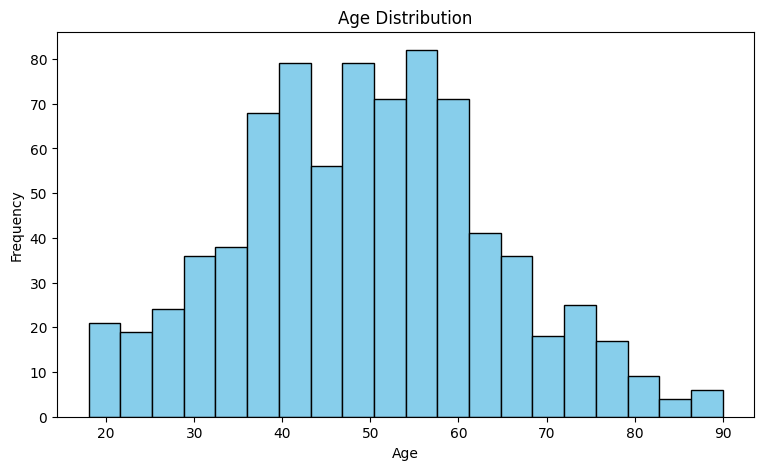

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["age"], bins=20, color="skyblue", edgecolor="black")
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
plt.show()

Shows the distribution of ages

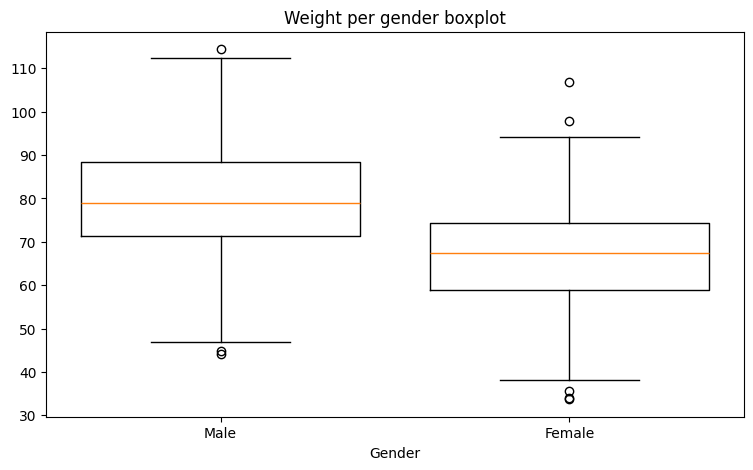

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([df[df["sex"] == "M"]["weight"],
			df[df["sex"] == "F"]["weight"]],
			tick_labels=["Male", "Female"],
			widths=0.8)
ax.set_title("Weight per gender boxplot")
ax.set_xlabel("Gender")
plt.show()

Shows the weight per gender. Dots outside are outliers.

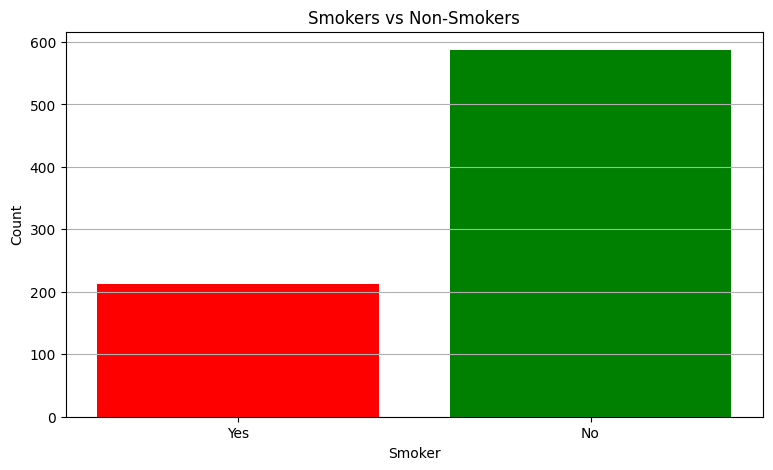

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

x = ["Yes", "No"]
y = [df[df["smoker"] == "Yes"]["smoker"].count(), df[df["smoker"] == "No"]["smoker"].count()]

ax.bar(x, y, color=["red", "green"])
ax.set_title("Smokers vs Non-Smokers")
ax.set_xlabel("Smoker")
ax.set_ylabel("Count")
ax.grid(axis="y")
plt.show()

Compares the amount of smokers vs non-smokers.

In [6]:
# Calculating number of sick and healthy individuals and sick rate
actual_sick = df[df["disease"] == 1]["systolic_bp"].count()
actual_healthy = df[df["disease"] == 0]["systolic_bp"].count()
actual_sick_rate = actual_sick / df.__len__()
print(actual_sick, actual_healthy, actual_sick_rate)

47 753 0.05875


Calculates the true count of sick vs healthy people and the sick rate of those.

In [7]:
# Simulate 1000 people with the same sick rate
n = 1000

sim_df = pd.DataFrame()
sim_df["id"] = range(1, n + 1)
sim_df["age"] = np.random.normal(df["age"].mean(), df["age"].std(), n).round().astype(int)
sim_df["sex"] = np.random.choice(["M", "F"], n)
sim_df["weight"] = np.random.normal(df["weight"].mean(), df["weight"].std(), n).round(1)
sim_df["height"] = np.random.normal(df["height"].mean(), df["height"].std(), n).round(1)
sim_df["systolic_bp"] = np.random.normal(df["systolic_bp"].mean(), df["systolic_bp"].std(), n).round().astype(float)
sim_df["cholesterol"] = np.random.normal(df["cholesterol"].mean(), df["cholesterol"].std(), n).round().astype(float)
sim_df["smoker"] = np.random.choice(["Yes", "No"], n)
sim_df["disease"] = np.random.choice([1, 0], n, p=[actual_sick_rate, 1 - actual_sick_rate])


In [8]:
# Sampling distribution of sickness rate
def sample_mean(_n, _sim_df) -> float:
	"""
	Calculates the sample mean of size _n from the population _pop
	Args:
		_n (int): Sample size
		_pop (array-like): Population
	Returns:
		float: Sample mean
	"""
	return np.mean(np.random.choice(_sim_df, size=_n, replace=False))

# How many sample means to calculate
R = 1000
means_n50 = np.array([sample_mean(50, sim_df["disease"]) for _ in range(R)])
means_n200 = np.array([sample_mean(200, sim_df["disease"]) for _ in range(R)])


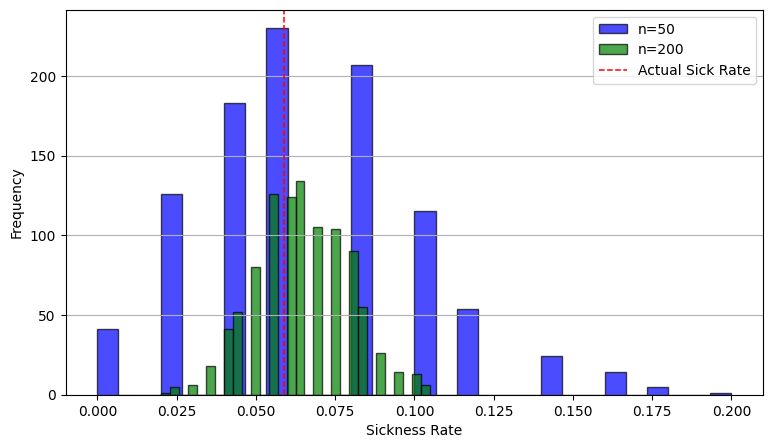

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(means_n50, bins=30, alpha=0.7, label="n=50", color="blue", edgecolor="black")
ax.hist(means_n200, bins=30, alpha=0.7, label="n=200", color="green", edgecolor="black")
ax.set_xlabel("Sickness Rate")
ax.set_ylabel("Frequency")
ax.axvline(actual_sick_rate, color="red", linestyle="dashed", linewidth=1.1, label="Actual Sick Rate")
ax.grid(axis="y")
ax.legend()
plt.show()

Compares the sick rate of a simulated population of 1000 with the true sick rate
We see that the simulated sick rate is shifted to the right of the true sick rate. This is likely due to our small simulated population that give rise to bigger fluctuations. If a larger simulated population size was used the simulated sick rate would get close to the true sick rate. Another likely reason is that a constant random seed is used and the simulated data got "stuck" at that shift. Using a random seed might resolve this.

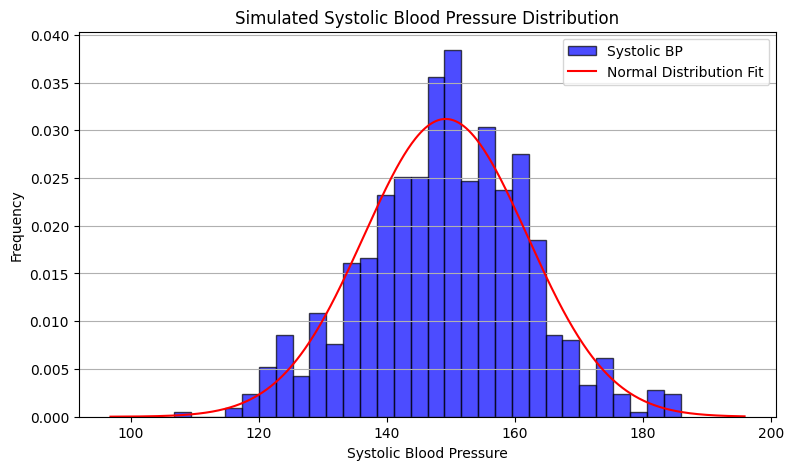

In [92]:
# Normal PDF function

def normal_pdf(_x, _m, _s):
	"""
	Calculates th y-values for the normal probability density function given x-values, mean and standard deviation.
	Args:
		_x (array-like): x-values
		_m (float): Mean
		_s (float): Standard deviation
	Returns:
		array-like: y-values
	"""
	_x = np.asarray(_x, dtype=float)
	if _s <= 0 or not np.isfinite(_s):
		raise ValueError("Standard deviation must be positive and finite!")
	
	norm = 1.0 / (_s * np.sqrt(2.0 * np.pi))
	z = (_x - _m) / _s
	y = norm * np.exp(-0.5 * z ** 2)
	return y

# Mean, median, std of simulated systolic blood pressure
mean_bp = np.mean(df["systolic_bp"])
median_bp = np.median(df["systolic_bp"])
std_bp = np.std(df["systolic_bp"], ddof=1)

# x and y values for normal pdf plot
x_values = np.linspace(df["systolic_bp"].min() - 10, df["systolic_bp"].max() + 10, 500)
y_values = normal_pdf(x_values, mean_bp, std_bp)

# Create fig and ax
fig, ax = plt.subplots(figsize=(9, 5))

# What to plot
ax.hist(df["systolic_bp"], bins=30, color="blue", alpha=0.7, edgecolor="black", label="Systolic BP", density=True)
ax.plot(x_values, y_values, color="red", label="Normal Distribution Fit")

# Plot settings
ax.set_title("Simulated Systolic Blood Pressure Distribution")
ax.set_xlabel("Systolic Blood Pressure")
ax.set_ylabel("Frequency")
ax.grid(axis="y")
ax.legend()
plt.show()


In [126]:
# Confidence Interval

# Normal Approximation Method Confidence Interval
def ci_mean_normal(_sample: np.array, _sample_size: int=50) -> tuple:
	"""
	Calculates the 95% confidence interval for the mean using the normal approximation method.
	Bounds: mean ± 1.96 * (std / sqrt(n))
	Args:
		_x (array-like): Sample data
		_sample_size (int): Size of sample
		_confidence (float): Confidence level
	Returns:
		tuple: Higher bound, lower bound, sample mean, sample std
	"""
	# Make sure that the sample can't be larger than the population
	if _sample_size > len(df):
		raise ValueError("Sample size can't be larger than population size!")
	
	_sample = np.asarray(_sample, dtype=float)
	mean = float(np.mean(_sample))
	std = float(np.std(_sample, ddof=1))
	n = len(_sample)
	z_crit = 1.96
	error = z_crit * (std / np.sqrt(n))
	return float(mean + error), float(mean - error), float(mean), float(std)

# Run 1000 randomized sample of the population and check that roughly 95% of the samples cover the actual_mean_sys_bp
actual_mean_sys_bp = float(df["systolic_bp"].mean())
sample_size = 50
runs = 1000
count = [0, 0]

# Rows for the dataframe of samples
rows = []

for i in range(runs):
	sample = np.random.choice(df["systolic_bp"], size=sample_size, replace=True)
	sample_hi, sample_lo, sample_mean, sample_std = ci_mean_normal(sample, sample_size)

	rows.append({
		"id": i,
		"high": sample_hi,
		"low": sample_lo,
		"mean": sample_mean,
		"std": sample_std,
		"in_interval": int(sample_lo < actual_mean_sys_bp < sample_hi)
	})

# Create dataframe of the samples
samples_df = pd.DataFrame(rows)

in_interval_rate = 1.0 - (samples_df[samples_df["in_interval"] == 0]["in_interval"].count() / samples_df[samples_df["in_interval"] == 1]["in_interval"].count())
print(f"{in_interval_rate * 100.0:.2f}% of the samples lie within the 95% confidence interval.")


93.96% of the samples lie within the 95% confidence interval.


Calculates the confidence interval 1000 times and checks the percentage of times it lies within the 95% confidence interval